<a href="https://colab.research.google.com/github/hanumadityanffm-cyber/kl-project/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# EXPERIMENT 2 – DATA PREPROCESSING

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop unnecessary columns
df.drop(columns=['deck', 'alive'], inplace=True, errors='ignore')

# Handle outliers in fare using IQR
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['fare'] = np.clip(df['fare'], lower, upper)

# One-hot encoding
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# Label encode remaining categorical
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split dataset
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print("Preprocessing Completed")

Preprocessing Completed


PCA ANALYSIS
Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Data preprocessing completed:
  Original data range: [0.10, 7.90]
  Standardized data mean: -0.00, std: 1.00
  Normalized data range: [0.00, 1.00]
--------------------------------------------------

Applying PCA on Standardized Data:
PCA Results:
  PC1: Explained Variance Ratio = 0.7296 (72.96%)
        Cumulative Variance = 0.7296 (72.96%)
  PC2: Explained Variance Ratio = 0.2285 (22.85%)
        Cumulative Variance = 0.9581 (95.81%)

Total variance explained by 2 components: 0.9581 (95.81%)
--------------------------------------------------


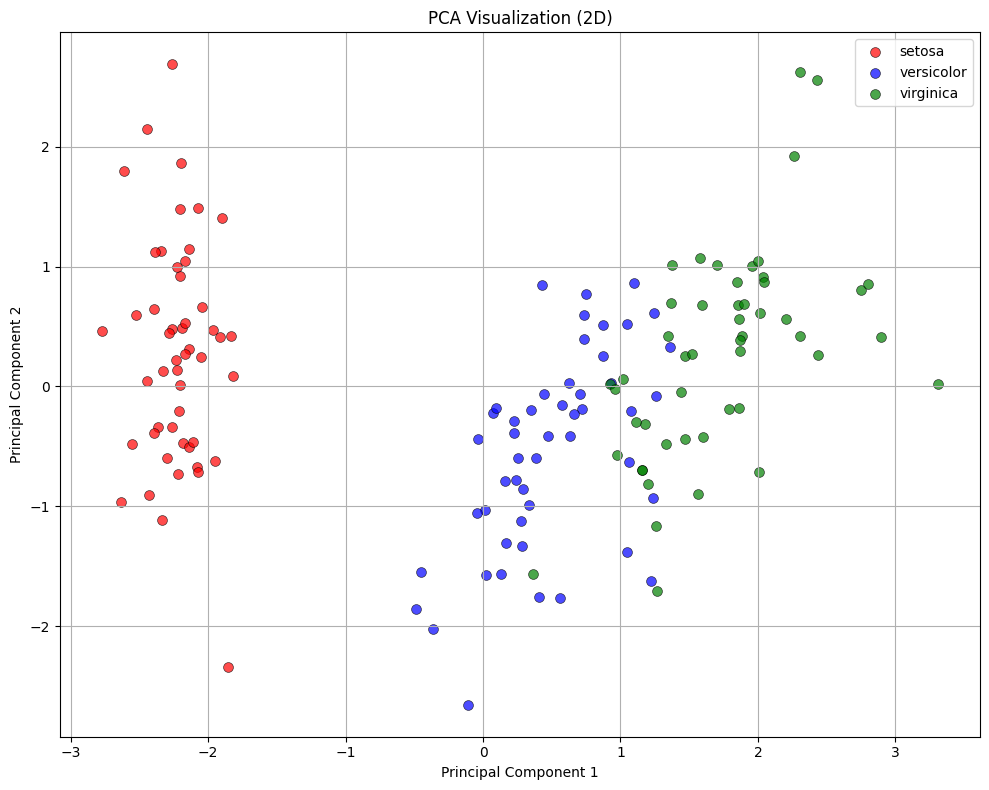


PCA Loadings:
Feature              PC1             PC2            
--------------------------------------------------
sepal length (cm)    0.8932          0.3620         
sepal width (cm)     -0.4617         0.8857         
petal length (cm)    0.9949          0.0235         
petal width (cm)     0.9682          0.0642         

Program Completed Successfully


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')


# ======================
# 1. Load Dataset
# ======================

def load_dataset(dataset_name='iris'):
    """Load either Iris or Wine dataset"""
    if dataset_name.lower() == 'iris':
        data = load_iris()
        print(f"Loaded Iris dataset")
    elif dataset_name.lower() == 'wine':
        data = load_wine()
        print(f"Loaded Wine dataset")
    else:
        raise ValueError("Dataset must be 'iris' or 'wine'")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(target_names)}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names


# ======================
# 2. Preprocessing
# ======================

def preprocess_data(X):
    """Apply both Standardization and Normalization"""

    scaler_standard = StandardScaler()
    X_standardized = scaler_standard.fit_transform(X)

    scaler_minmax = MinMaxScaler()
    X_normalized = scaler_minmax.fit_transform(X)

    print("Data preprocessing completed:")
    print(f"  Original data range: [{X.min():.2f}, {X.max():.2f}]")
    print(f"  Standardized data mean: {X_standardized.mean():.2f}, std: {X_standardized.std():.2f}")
    print(f"  Normalized data range: [{X_normalized.min():.2f}, {X_normalized.max():.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized


# ======================
# 3. PCA Implementation
# ======================

def apply_pca(X, n_components=2):
    """Apply PCA and reduce dimensions"""

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
        print(f"  PC{i + 1}: Explained Variance Ratio = {var:.4f} ({var * 100:.2f}%)")
        print(f"        Cumulative Variance = {cum_var:.4f} ({cum_var * 100:.2f}%)")

    print(
        f"\nTotal variance explained by {n_components} components: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1] * 100:.2f}%)")
    print("-" * 50)

    return X_pca, pca, explained_variance_ratio, cumulative_variance


# ======================
# 4. Visualization
# ======================

def plot_pca_2d(X_pca, y, target_names, title="PCA Visualization (2D)"):
    plt.figure(figsize=(10, 8))

    colors = ['red', 'blue', 'green', 'purple', 'orange']

    for i, target_name in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                    alpha=0.7, s=50, c=colors[i % len(colors)],
                    label=target_name, edgecolor='k', linewidth=0.5)

    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ======================
# 5. Main
# ======================

def main():
    print("=" * 70)
    print("PCA ANALYSIS")
    print("=" * 70)

    X, y, feature_names, target_names = load_dataset('iris')
    X_standardized, X_normalized = preprocess_data(X)

    print("\nApplying PCA on Standardized Data:")
    X_pca_standard, pca_standard, evr_standard, cum_var_standard = apply_pca(X_standardized, 2)

    plot_pca_2d(X_pca_standard, y, target_names)

    print("\nPCA Loadings:")
    loadings = pca_standard.components_.T * np.sqrt(pca_standard.explained_variance_)

    print(f"{'Feature':<20} {'PC1':<15} {'PC2':<15}")
    print("-" * 50)
    for i, feature in enumerate(feature_names):
        print(f"{feature:<20} {loadings[i, 0]:<15.4f} {loadings[i, 1]:<15.4f}")

    print("\nProgram Completed Successfully")


if __name__ == "__main__":
    main()

PART A: LINEAR REGRESSION

1. Creating synthetic regression dataset...
Training set size: 240 samples
Testing set size: 60 samples

2. Training Linear Regression model...

3. Model Performance Metrics:
----------------------------------------
Training MSE: 228.8446
Testing MSE: 240.0475
Training MAE: 12.1294
Testing MAE: 12.0117
Training R² Score: 0.7564
Testing R² Score: 0.7986

4. Model Coefficients:
----------------------------------------
Intercept (β₀): 0.3065
Coefficient (β₁): 27.6115


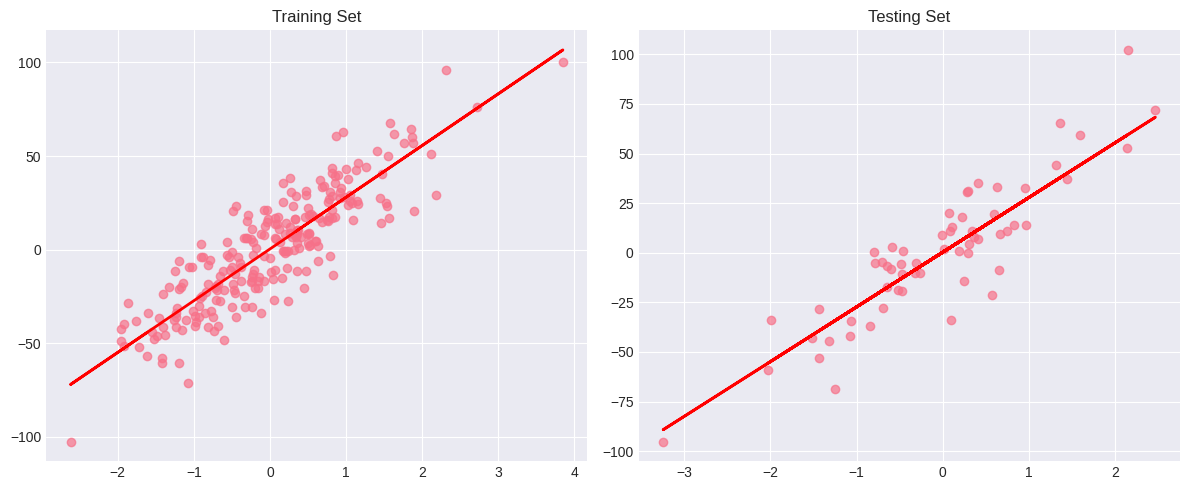


PART B: LOGISTIC REGRESSION

1. Loading Breast Cancer dataset...

2. Training Logistic Regression model...

3. Model Performance Metrics:
----------------------------------------
Accuracy: 0.9883
Precision: 0.9907
Recall: 0.9907
F1-Score: 0.9907


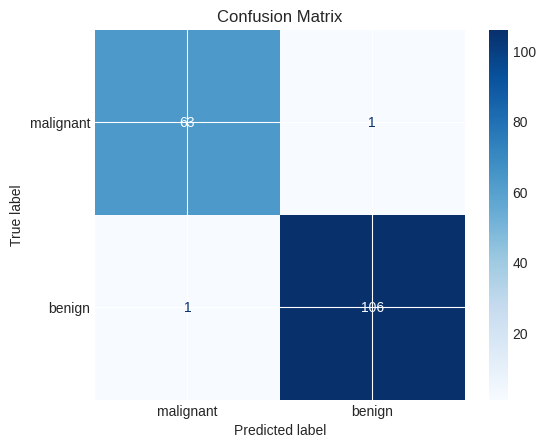


Program Completed Successfully


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================
# PART A: LINEAR REGRESSION
# ============================

print("=" * 60)
print("PART A: LINEAR REGRESSION")
print("=" * 60)

print("\n1. Creating synthetic regression dataset...")
X, y = make_regression(n_samples=300, n_features=1, noise=15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("\n2. Training Linear Regression model...")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n3. Model Performance Metrics:")
print("-" * 40)
print(f"Training MSE: {mse_train:.4f}")
print(f"Testing MSE: {mse_test:.4f}")
print(f"Training MAE: {mae_train:.4f}")
print(f"Testing MAE: {mae_test:.4f}")
print(f"Training R² Score: {r2_train:.4f}")
print(f"Testing R² Score: {r2_test:.4f}")

print("\n4. Model Coefficients:")
print("-" * 40)
print(f"Intercept (β₀): {linear_model.intercept_:.4f}")
print(f"Coefficient (β₁): {linear_model.coef_[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_train, y_train, alpha=0.7, label='Actual data')
axes[0].plot(X_train, y_train_pred, color='red', linewidth=2)
axes[0].set_title('Training Set')

axes[1].scatter(X_test, y_test, alpha=0.7)
axes[1].plot(X_test, y_test_pred, color='red', linewidth=2)
axes[1].set_title('Testing Set')

plt.tight_layout()
plt.show()

# ============================
# PART B: LOGISTIC REGRESSION
# ============================

print("\n" + "=" * 60)
print("PART B: LOGISTIC REGRESSION")
print("=" * 60)

print("\n1. Loading Breast Cancer dataset...")
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n2. Training Logistic Regression model...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

y_test_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n3. Model Performance Metrics:")
print("-" * 40)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print("\nProgram Completed Successfully")

PART A: GINI AND ENTROPY CALCULATION
Gini Index: 0.5000
Entropy: 1.0000

PART B: DECISION TREE ON IRIS DATASET
Accuracy (Gini): 1.0000
Accuracy (Entropy): 0.9778


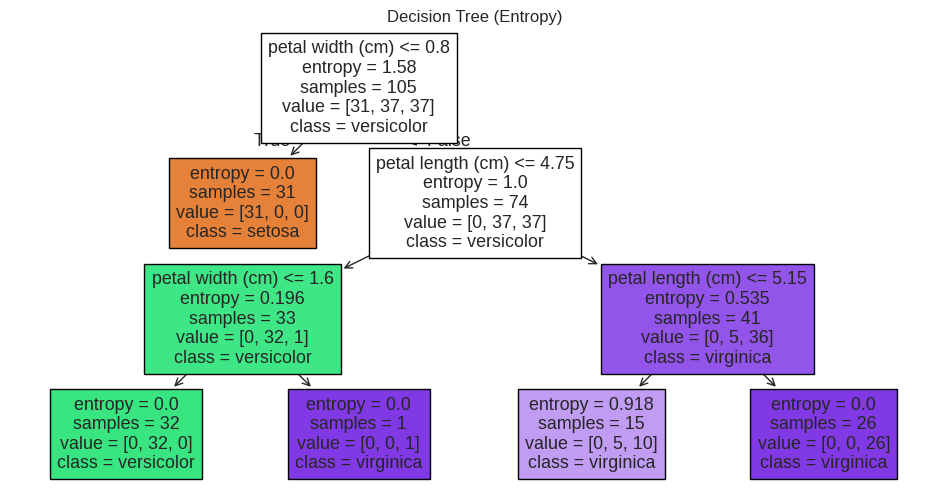


Program Completed Successfully


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# ===============================
# PART A: Manual Gini & Entropy
# ===============================

print("=" * 60)
print("PART A: GINI AND ENTROPY CALCULATION")
print("=" * 60)

y_sample = np.array([0, 0, 1, 1])

# Gini Index
p0 = np.mean(y_sample == 0)
p1 = np.mean(y_sample == 1)
gini = 1 - (p0**2 + p1**2)

# Entropy
entropy = - (p0 * np.log2(p0) + p1 * np.log2(p1))

print(f"Gini Index: {gini:.4f}")
print(f"Entropy: {entropy:.4f}")

# ===============================
# PART B: Decision Tree on Iris
# ===============================

print("\n" + "=" * 60)
print("PART B: DECISION TREE ON IRIS DATASET")
print("=" * 60)

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Decision Tree (Gini)
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=3)
dt_gini.fit(X_train, y_train)

# Train Decision Tree (Entropy)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt_entropy.fit(X_train, y_train)

# Predictions
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

# Accuracy
acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Accuracy (Gini): {acc_gini:.4f}")
print(f"Accuracy (Entropy): {acc_entropy:.4f}")

# ===============================
# Visualization
# ===============================

plt.figure(figsize=(12, 6))
plot_tree(dt_entropy, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.title("Decision Tree (Entropy)")
plt.show()

print("\nProgram Completed Successfully")

EXPERIMENT 6: KNN AND NAIVE BAYES

Loading Iris dataset...

Training KNN model...
KNN Accuracy: 1.0000


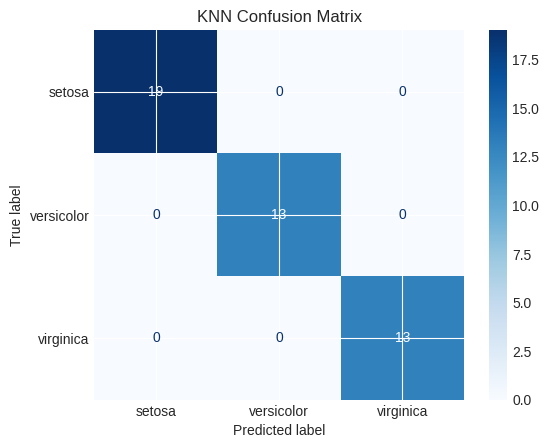


Training Gaussian Naive Bayes model...
Naive Bayes Accuracy: 0.9778


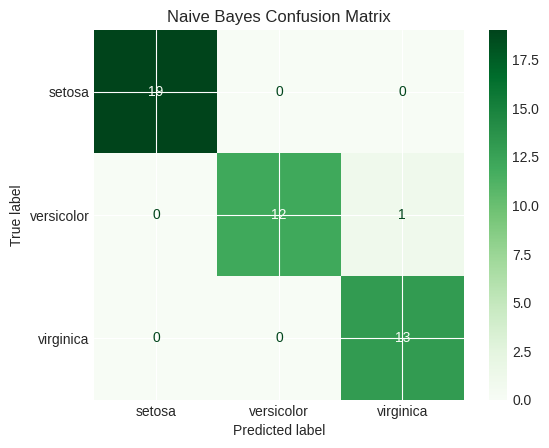


Program Completed Successfully


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("=" * 60)
print("EXPERIMENT 6: KNN AND NAIVE BAYES")
print("=" * 60)

# ============================
# PART A: K-NEAREST NEIGHBOR
# ============================

print("\nLoading Iris dataset...")
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nTraining KNN model...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {acc_knn:.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                  display_labels=iris.target_names)
disp_knn.plot(cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

# ============================
# PART B: NAIVE BAYES
# ============================

print("\nTraining Gaussian Naive Bayes model...")
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {acc_nb:.4f}")

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                                 display_labels=iris.target_names)
disp_nb.plot(cmap='Greens')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

print("\nProgram Completed Successfully")

Digits dataset loaded. Training with Random Forest and AdaBoost...
Training samples: 1437, Test samples: 360

PART A: RANDOM FOREST
Best RF params: {'max_depth': 10, 'n_estimators': 200}
RF Accuracy: 0.9722, OOB Error: 0.0278
RF Train time: 0.956s, Predict time: 0.025s

PART B: ADABOOST
Best AdaBoost params: {'learning_rate': 1.0, 'n_estimators': 200}
AdaBoost Accuracy: 0.8639
AdaBoost Train time: 0.935s, Predict time: 0.052s


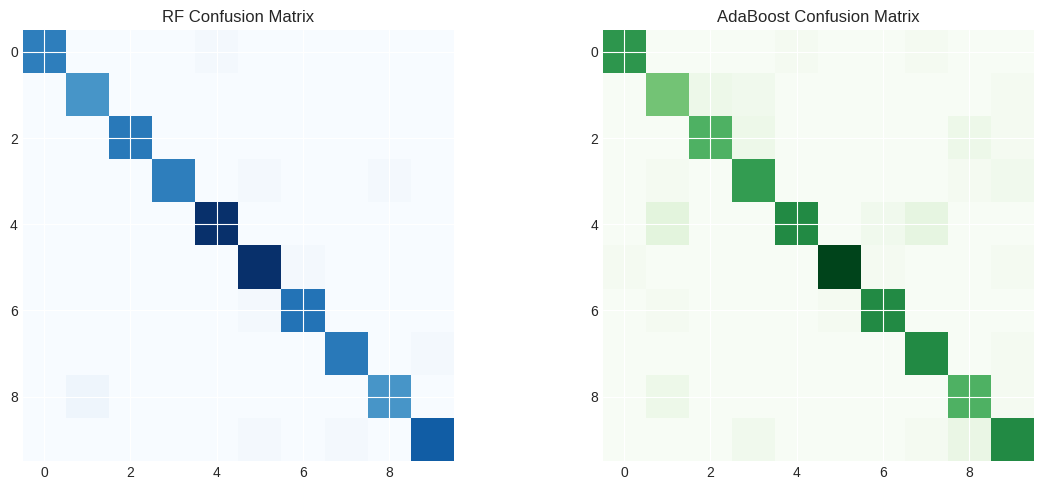


PROGRAM COMPLETED SUCCESSFULLY


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Digits dataset loaded. Training with Random Forest and AdaBoost...")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ==================== PART A: RANDOM FOREST ====================

print("\n" + "="*50 + "\nPART A: RANDOM FOREST\n" + "="*50)

rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}
rf_grid = GridSearchCV(RandomForestClassifier(oob_score=True, random_state=42),
                       rf_params, cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

start_time = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start_time

start_time = time.time()
y_pred_rf = rf.predict(X_test)
rf_pred_time = time.time() - start_time

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Best RF params: {rf_grid.best_params_}")
print(f"RF Accuracy: {rf_accuracy:.4f}, OOB Error: {1-rf.oob_score_:.4f}")
print(f"RF Train time: {rf_train_time:.3f}s, Predict time: {rf_pred_time:.3f}s")

# ==================== PART B: ADABOOST ====================

print("\n" + "="*50 + "\nPART B: ADABOOST\n" + "="*50)

base_dt = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_dt, random_state=42),
    ada_params,
    cv=3,
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)
ada = ada_grid.best_estimator_

start_time = time.time()
ada.fit(X_train, y_train)
ada_train_time = time.time() - start_time

start_time = time.time()
y_pred_ada = ada.predict(X_test)
ada_pred_time = time.time() - start_time

ada_accuracy = accuracy_score(y_test, y_pred_ada)

print(f"Best AdaBoost params: {ada_grid.best_params_}")
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")
print(f"AdaBoost Train time: {ada_train_time:.3f}s, Predict time: {ada_pred_time:.3f}s")

# ==================== VISUALIZATIONS ====================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
axes[0].imshow(cm_rf, cmap='Blues')
axes[0].set_title('RF Confusion Matrix')

cm_ada = confusion_matrix(y_test, y_pred_ada)
axes[1].imshow(cm_ada, cmap='Greens')
axes[1].set_title('AdaBoost Confusion Matrix')

plt.tight_layout()
plt.show()

print("\nPROGRAM COMPLETED SUCCESSFULLY")

EXPERIMENT 8: SUPPORT VECTOR MACHINE
SVM Accuracy: 0.6889


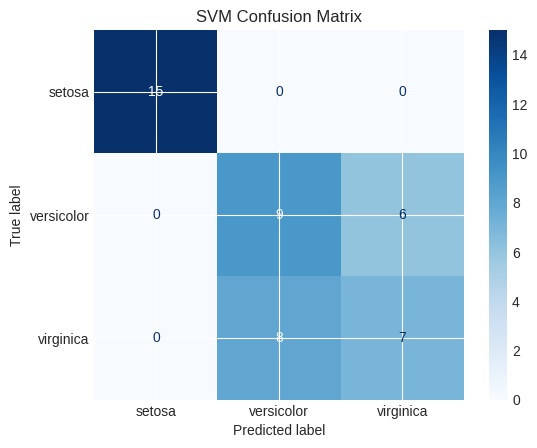

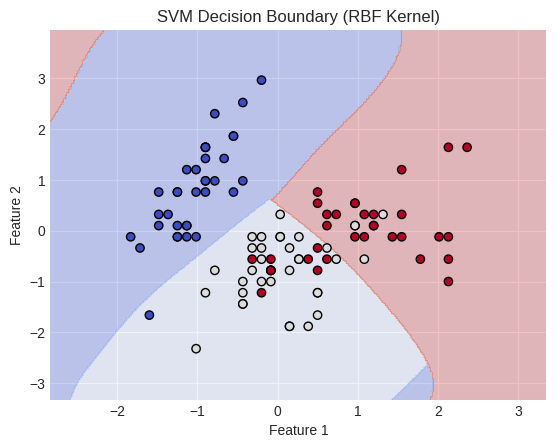


Program Completed Successfully


In [8]:
# EXPERIMENT 8 – SUPPORT VECTOR MACHINE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("EXPERIMENT 8: SUPPORT VECTOR MACHINE")
print("=" * 60)

# ===============================
# 1. Load Dataset
# ===============================

iris = load_iris()
X = iris.data
y = iris.target

# Use only first two features for visualization
X = X[:, :2]

# ===============================
# 2. Split Dataset
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ===============================
# 3. Feature Scaling
# ===============================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 4. Train SVM Model
# ===============================

svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)

# ===============================
# 5. Predictions & Accuracy
# ===============================

y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"SVM Accuracy: {accuracy:.4f}")

# ===============================
# 6. Confusion Matrix
# ===============================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.show()

# ===============================
# 7. Decision Boundary Visualization
# ===============================

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("SVM Decision Boundary (RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("\nProgram Completed Successfully")